In [104]:
%reset -f

In [105]:
%%bash

wget -nc -q --show-progress https://raw.githubusercontent.com/fvicini/RBM_ML_2026/c47fccb4c3aa8e204239c3a7b5057d9deba46920/other_utilities.py

if [ ! -d "Meshes" ]; then
  git init temp_repo -q && cd temp_repo
  git remote add origin https://github.com/fvicini/RBM_ML_2026.git
  git config core.sparseCheckout true
  echo "Meshes/*" >> .git/info/sparse-checkout
  git fetch --depth 1 origin c47fccb4c3aa8e204239c3a7b5057d9deba46920 -q
  git checkout FETCH_HEAD -q
  mv Meshes ../
  cd .. && rm -rf temp_repo
fi

# **Navier-Stokes: POD vs POD-NN**
## Model Order Reduction and Machine Learning
### Matteo Salicandro, Matteo Tedde

In [106]:
import importlib
import numpy as np
import argparse
import os.path
import scipy.sparse
import vtk
from pypolydim import polydim, gedim
from pypolydim.export_vtk_utilities import ExportVTKUtilities
from pypolydim.assembler_utilities import assembler_utilities
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import time
import functions
from functions import *

importlib.reload(functions)
np.random.seed(67)

import sys
sys.path.insert(1, '../')
import other_utilities as other_ut

In [107]:
geometry_utilities_config = gedim.GeometryUtilitiesConfig()
geometry_utilities_config.tolerance1_d = 1.0e-6
geometry_utilities_config.tolerance2_d = 1.0e-12
geometry_utilities = gedim.GeometryUtilities(geometry_utilities_config)
mesh_utilities = gedim.MeshUtilities()
vtk_utilities = ExportVTKUtilities()

In [108]:
# Export folder
export_file_path = "./Export/Test_1"
if not os.path.exists(export_file_path):
    os.makedirs(export_file_path)

# Mesh file path
export_mesh_path = export_file_path + "/Mesh"
if not os.path.exists(export_mesh_path):
    os.makedirs(export_mesh_path)

# Solution file path
export_solution_path = export_file_path + "/Solution"
if not os.path.exists(export_solution_path):
    os.makedirs(export_solution_path)

In [109]:
pde_domain = polydim.pde_tools.mesh.pde_mesh_utilities.PDE_Domain_2D()
pde_domain.vertices = np.array([[0.0, 1.0, 1.0, 0.0],
                                [0.0, 0.0, 1.0, 1.0],
                                [0.0, 0.0, 0.0, 0.0]])
pde_domain.shape_type = polydim.pde_tools.mesh.pde_mesh_utilities.PDE_Domain_2D.Domain_Shape_Types.parallelogram
pde_domain.area = 1.0

In [110]:
mesh_type = polydim.pde_tools.mesh.pde_mesh_utilities.MeshGenerator_Types_2D.triangular
method_type = polydim.pde_tools.local_space_pcc_2_d.MethodTypes.fem_pcc
mesh_size = 0.001

In [111]:
mesh_data = gedim.MeshMatrices()
mesh = gedim.MeshMatricesDAO(mesh_data)

polydim.pde_tools.mesh.pde_mesh_utilities.create_mesh_2_d(geometry_utilities,
                                                          mesh_utilities,
                                                          mesh_type,
                                                          pde_domain,
                                                          mesh_size,
                                                          mesh)
mesh_geometric_data = polydim.pde_tools.mesh.pde_mesh_utilities.compute_mesh_2_d_geometry_data(geometry_utilities, mesh_utilities, mesh)

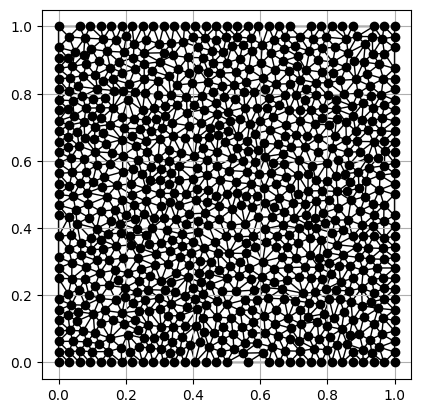

In [112]:
vtk_utilities.export_mesh(export_mesh_path, mesh)
other_ut.plot_mesh(mesh)

In [113]:
info_internal = polydim.pde_tools.do_fs.DOFsManager.MeshDOFsInfo.BoundaryInfo(polydim.pde_tools.do_fs.DOFsManager.MeshDOFsInfo.BoundaryInfo.BoundaryTypes.none)
info_internal.marker = 0

info_dirichlet = polydim.pde_tools.do_fs.DOFsManager.MeshDOFsInfo.BoundaryInfo(polydim.pde_tools.do_fs.DOFsManager.MeshDOFsInfo.BoundaryInfo.BoundaryTypes.strong)
info_dirichlet.marker = 1

info_neumann_none = polydim.pde_tools.do_fs.DOFsManager.MeshDOFsInfo.BoundaryInfo(polydim.pde_tools.do_fs.DOFsManager.MeshDOFsInfo.BoundaryInfo.BoundaryTypes.none)
info_neumann_none.marker = 0

pressure_boundary_info = {
    0: info_internal,
    1: info_dirichlet,
    2: info_neumann_none,
    3: info_neumann_none,
    4: info_neumann_none,
    5: info_neumann_none,
    6: info_neumann_none,
    7: info_neumann_none,
    8: info_neumann_none
}

speed_boundary_info = {
    0: info_internal,
    1: info_dirichlet,
    2: info_dirichlet,
    3: info_dirichlet,
    4: info_dirichlet,
    5: info_dirichlet,
    6: info_dirichlet,
    7: info_dirichlet,
    8: info_dirichlet
}

In [114]:
mesh_connectivity_data = polydim.pde_tools.mesh.MeshMatricesDAO_mesh_connectivity_data(mesh)

pressure_reference_element_data = polydim.pde_tools.local_space_pcc_2_d.create_reference_element(method_type,
                                                                                              1)
speed_reference_element_data = polydim.pde_tools.local_space_pcc_2_d.create_reference_element(method_type,
                                                                                             2)

dof_manager = polydim.pde_tools.do_fs.DOFsManager()

pressure_mesh_dofs_info = polydim.pde_tools.local_space_pcc_2_d.set_mesh_do_fs_info(pressure_reference_element_data,
                                                                                    mesh,
                                                                                    pressure_boundary_info)
pressure_dofs_data = dof_manager.create_do_fs_2_d(pressure_mesh_dofs_info,
                                                  mesh_connectivity_data)

speed_mesh_dofs_info = polydim.pde_tools.local_space_pcc_2_d.set_mesh_do_fs_info(speed_reference_element_data,
                                                                                 mesh,
                                                                                 speed_boundary_info)
speed_dofs_data = dof_manager.create_do_fs_2_d(speed_mesh_dofs_info,
                                               mesh_connectivity_data)

In [115]:
pressure_n_dofs = pressure_dofs_data.number_do_fs
pressure_n_strongs = pressure_dofs_data.number_strongs
speed_n_dofs = speed_dofs_data.number_do_fs
speed_n_strongs = speed_dofs_data.number_strongs
tot_dofs = 2 * speed_n_dofs + pressure_n_dofs
tot_strongs = 2 * speed_n_strongs + pressure_n_strongs

In [116]:
print("P dofs\t", "P stgs\t", "U dofs\t", "U stgs\t", "T dofs\t", "T stgs")
print(pressure_n_dofs,"\t", pressure_n_strongs,"\t", speed_n_dofs,"\t", speed_n_strongs,"\t", tot_dofs,"\t", tot_strongs)

P dofs	 P stgs	 U dofs	 U stgs	 T dofs	 T stgs
829 	 1 	 2966 	 234 	 6761 	 469


In [117]:
snapshot_num = 50
snapshots = generate_snapshots(snapshot_num, geometry_utilities, vtk_utilities, mesh, mesh_geometric_data, tot_dofs, export_solution_path,
                       speed_n_dofs, speed_mesh_dofs_info, speed_dofs_data, speed_reference_element_data, speed_n_strongs,
                       pressure_n_dofs, pressure_mesh_dofs_info, pressure_dofs_data, pressure_reference_element_data, pressure_n_strongs)
snapshots

Generating Snapshots: 100%|██████████| 50/50 [00:40<00:00,  1.24it/s]


array([[ 2.45453980e-03, -2.36021996e-02, -6.17908814e-03, ...,
         1.36562914e+00,  4.29096348e+00, -1.05790185e+00],
       [-2.02392022e-02, -7.48396000e-03,  1.33506265e-02, ...,
         7.58936961e-01,  1.72045254e+00,  5.19268282e-01],
       [-7.40492551e-02, -5.31719048e-03,  2.05034416e-01, ...,
         8.46554060e-01,  2.67075055e+00,  1.68030021e-01],
       ...,
       [-1.77380321e-02, -6.57168152e-03,  1.14027302e-02, ...,
         7.47707050e-01,  1.68844305e+00,  5.23682479e-01],
       [ 1.48155953e-01, -3.75906111e-01,  2.28335558e-01, ...,
        -7.47142958e-01, -4.43345259e+00, -6.65978920e-01],
       [ 6.57007079e-04, -1.30824490e-02, -1.07337145e-03, ...,
         2.72586967e+00,  5.65727940e+00, -1.11665658e+00]],
      shape=(50, 6761))